### Light Gradient Boosting

 - Light Gradient Boosting is and open source boosting framework designed for efficient and scalable.
 - Works both structured and unstructured data, optimized for speed and memory usage**

In [38]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('medical_cost.csv')
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   str    
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   str    
 6   region    1338 non-null   str    
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), str(3)
memory usage: 83.8 KB


*EDA: analyze patterns, distributions and relationships among features.*

In [40]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
  grouped_data = df[[col, 'charges']].groupby(col).mean()
  print(f"Mean charges by {col}")
  print(grouped_data)
  print()

Mean charges by sex
             charges
sex                 
female  12569.578844
male    13956.751178

Mean charges by smoker
             charges
smoker              
no       8434.268298
yes     32050.231832

Mean charges by region
                charges
region                 
northeast  13406.384516
northwest  12417.575374
southeast  14735.411438
southwest  12346.937377



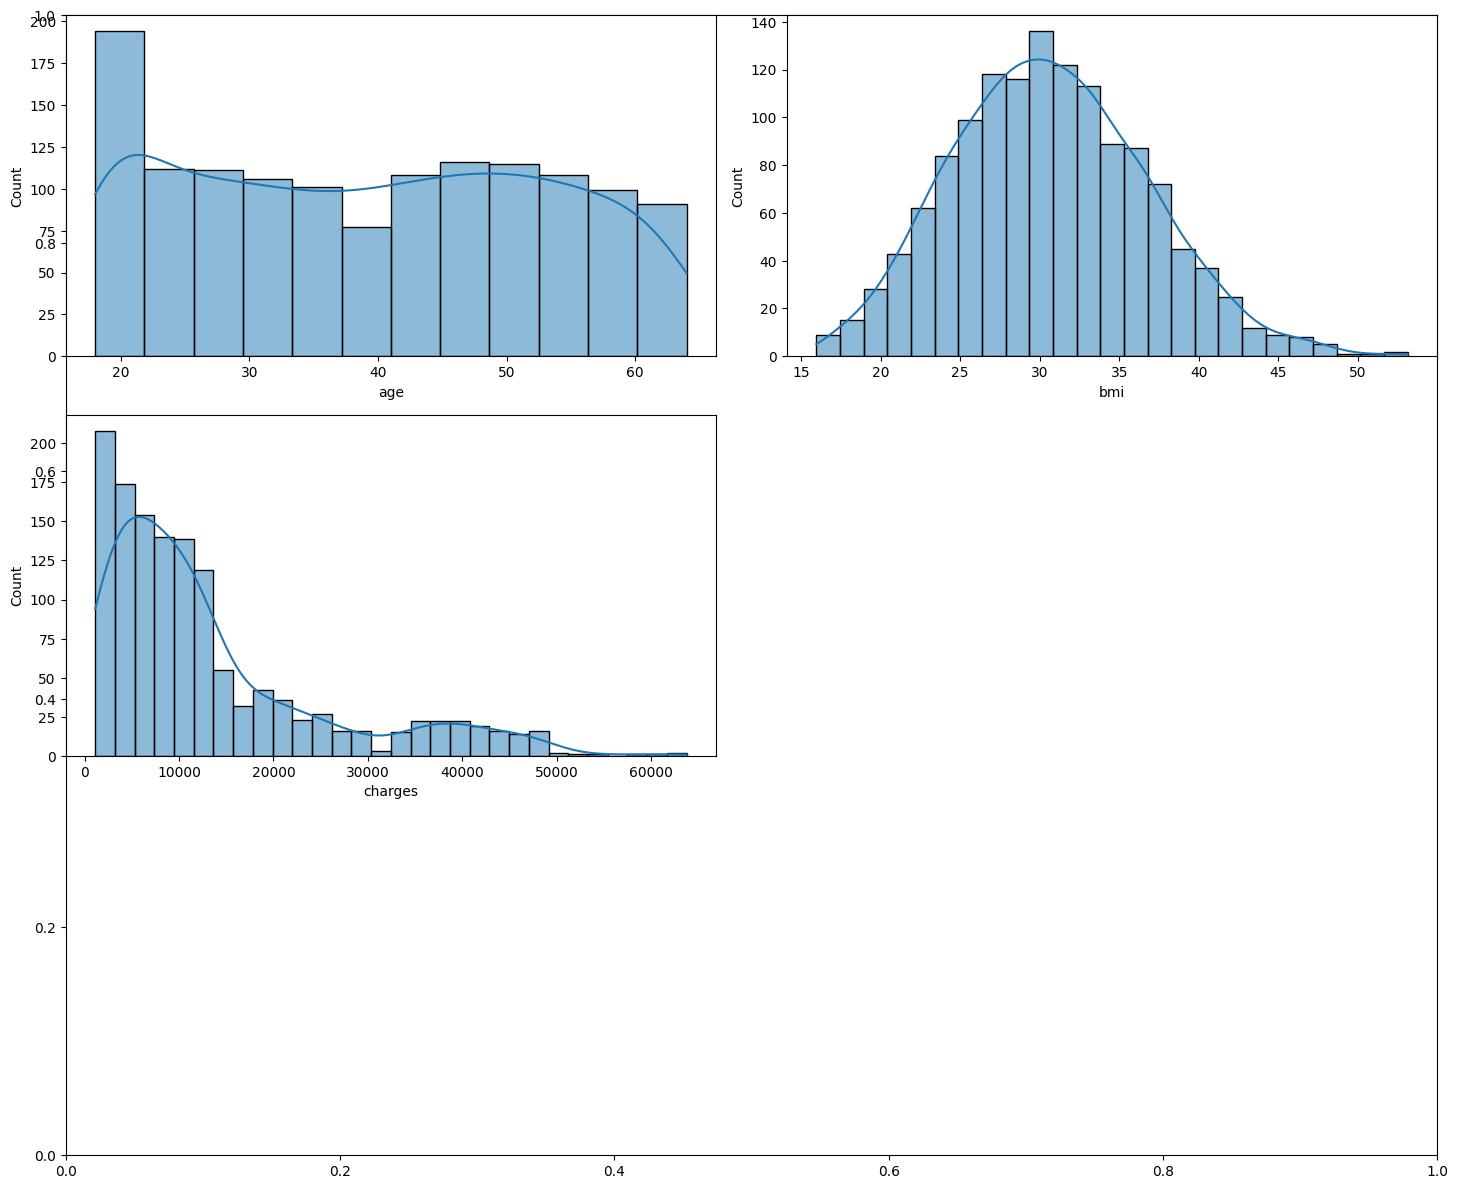

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['age', 'bmi', 'charges']

plt.subplots(figsize=(15, 12))
for i, col in enumerate(numeric_cols):
  plt.subplot(3, 2, i+1)
  sns.histplot(df[col], kde=True)

plt.tight_layout()
plt.show()  

##### Data Preprocessing

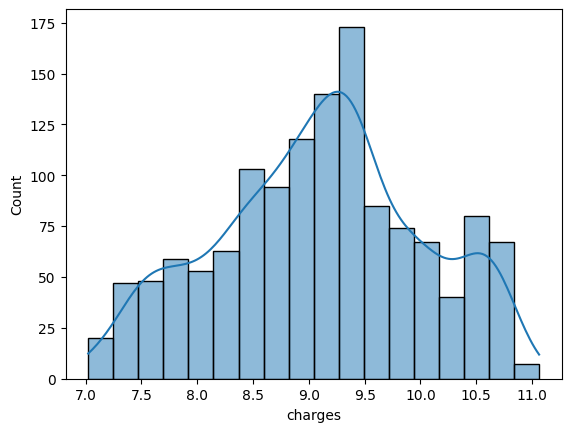

In [42]:
import numpy as np

df['charges'] = np.log1p(df['charges'])
sns.histplot(df['charges'], kde=True)
plt.show()

**Encoding categorical feature**

In [43]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,1,27.900,0,1,southwest,9.734236
1,2,18,0,33.770,1,0,southeast,7.453882
2,3,28,0,33.000,3,0,southeast,8.400763
3,4,33,0,22.705,0,0,northwest,9.998137
4,5,32,0,28.880,0,0,northwest,8.260455


**We will apply one-hot encoding on the region multiclass**

In [44]:
df = pd.concat([df, pd.get_dummies(df['region']).astype('int')], axis=1)
df.drop(['Id', 'region'], inplace=True, axis=1)
df.head()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,9.734236,0,0,0,1
1,18,0,33.770,1,0,7.453882,0,0,1,0
2,28,0,33.000,3,0,8.400763,0,0,1,0
3,33,0,22.705,0,0,9.998137,0,1,0,0
4,32,0,28.880,0,0,8.260455,0,1,0,0


In [45]:
from sklearn.model_selection import train_test_split

features = df.drop('charges', axis=1)
target = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
  features, target,
  test_size=0.2,
  random_state=42
)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

In [48]:
params = {
  'objective': 'regression',
  'metric': 'rmse',
  'boosting_type': 'gbdt',
  'num_leaves': 31,
  'learning_rate': 0.05,
  'feature_fraction': 0.9
}

num_round = 100
bst = lgb.train(
  params, train_data, num_round, 
  valid_sets=[test_data]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 328
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 9
[LightGBM] [Info] Start training from score 9.113489


In [50]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error as mse

model = LGBMRegressor(metric='rmse')
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_test)

print("Training RMSE: ", np.sqrt(mse(y_train, y_train_pred)))
print("Validation RMSE: ", np.sqrt(mse(y_test, y_val_pred)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002263 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 328
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 9
[LightGBM] [Info] Start training from score 9.113489
Training RMSE:  0.0683520850674947
Validation RMSE:  0.36412221278449
